In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from itertools import combinations

In [22]:
df = pd.read_csv("../results/algorithm_comparison.csv")

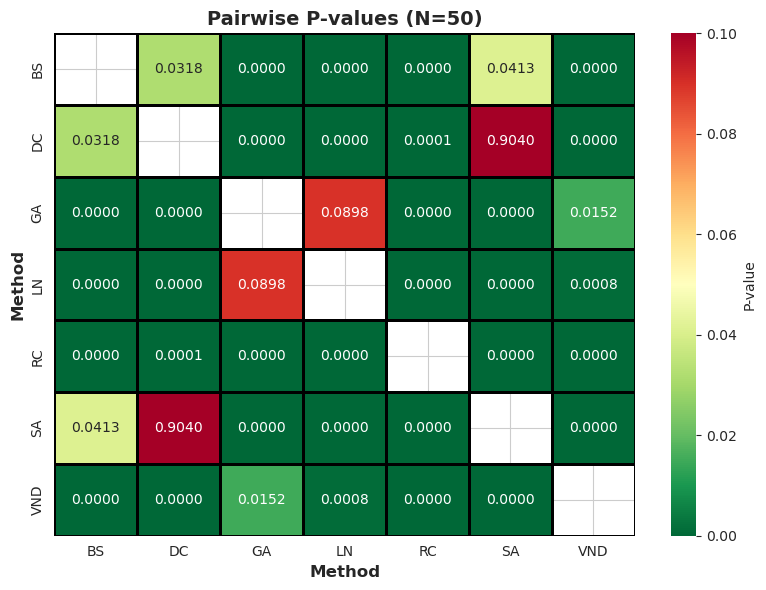

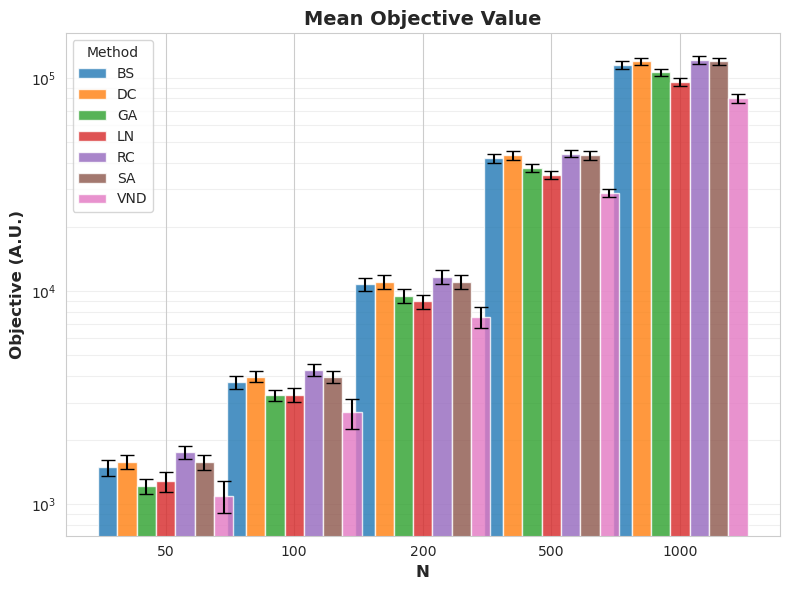

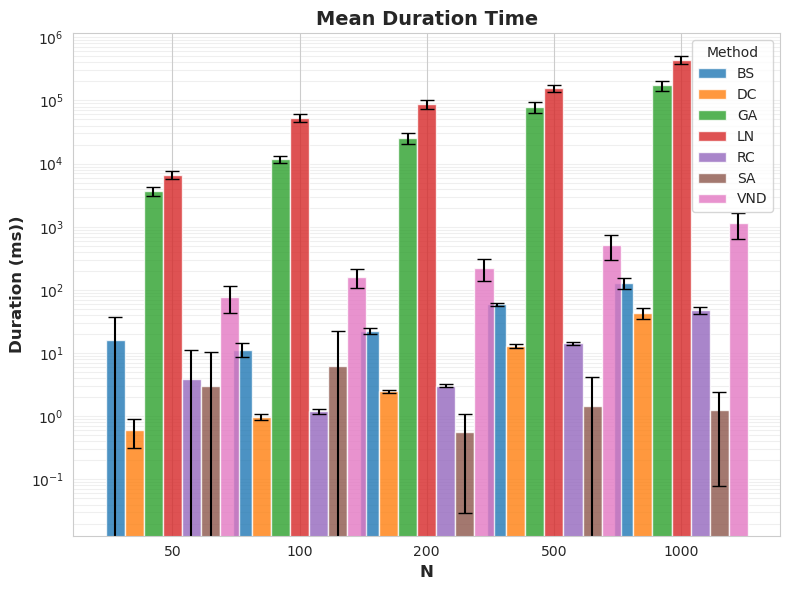


STATISTICAL SUMMARY (N=50)

Objective Stats:
         count       mean         std       min        25%       50%  \
method                                                                
BS       20.0  1490.6820  129.910117  1248.560  1378.8300  1481.930   
DC       20.0  1579.7895  122.782873  1406.810  1466.9750  1574.065   
GA       20.0  1214.8780  103.090220  1018.440  1161.9375  1211.660   
LN       20.0  1281.9025  137.874964  1057.770  1178.6050  1270.500   
RC       20.0  1754.0485  123.345948  1513.970  1686.3450  1734.100   
SA       20.0  1575.0765  122.696094  1404.070  1466.6825  1574.065   
VND      20.0  1095.0058  184.007895   903.311  1035.5200  1060.830   

              75%      max  
method                      
BS      1546.1125  1745.58  
DC      1653.2150  1828.01  
GA      1250.8075  1454.18  
LN      1301.8200  1666.24  
RC      1831.9900  1994.60  
SA      1650.9525  1822.70  
VND     1126.8725  1804.27  

Duration Stats:
         count         mean        

In [25]:
sns.set_style("whitegrid")

n_fixed = df['N'].unique()[0]
data_n = df[df['N'] == n_fixed]
methods = sorted(data_n['method'].unique())

# Plot 1: P-value Heatmap
fig1, ax1 = plt.subplots(figsize=(8, 6))
pvalue_matrix = np.ones((len(methods), len(methods)))
for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i != j:
            g1 = data_n[data_n['method'] == m1]['objective'].values
            g2 = data_n[data_n['method'] == m2]['objective'].values
            _, pval = stats.ttest_ind(g1, g2)
            pvalue_matrix[i, j] = pval

mask = np.eye(len(methods), dtype=bool)
sns.heatmap(pvalue_matrix, annot=True, fmt='.4f', cmap='RdYlGn_r', 
            xticklabels=methods, yticklabels=methods, ax=ax1,
            mask=mask, vmin=0, vmax=0.1, cbar_kws={'label': 'P-value'},
            linewidths=1, linecolor='black')
ax1.set_title(f'Pairwise P-values (N={n_fixed})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Method', fontsize=12, fontweight='bold')
ax1.set_ylabel('Method', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('algo_pvalue_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Objective Values
fig2, ax2 = plt.subplots(figsize=(8, 6))
summary_obj = df.groupby(['N', 'method'])['objective'].agg(['mean', 'std']).reset_index()
x_pos = np.arange(len(summary_obj['N'].unique()))
width = 0.15

for i, method in enumerate(methods):
    method_data = summary_obj[summary_obj['method'] == method]
    offset = width * (i - len(methods)/2 + 0.5)
    ax2.bar(x_pos + offset, method_data['mean'], width, yerr=method_data['std'],
           label=method, capsize=5, alpha=0.8)

ax2.set_yscale('log')
ax2.set_xlabel('N', fontsize=12, fontweight='bold')
ax2.set_ylabel('Objective (A.U.)', fontsize=12, fontweight='bold')
ax2.set_title('Mean Objective Value', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(summary_obj['N'].unique())
ax2.legend(title='Method')
ax2.grid(axis='y', alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('algo_objective_values.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Duration Times
fig3, ax3 = plt.subplots(figsize=(8, 6))
summary_dur = df.groupby(['N', 'method'])['duration'].agg(['mean', 'std']).reset_index()

for i, method in enumerate(methods):
    method_data = summary_dur[summary_dur['method'] == method]
    offset = width * (i - len(methods)/2 + 0.5)
    ax3.bar(x_pos + offset, method_data['mean'], width, yerr=method_data['std'],
           label=method, capsize=5, alpha=0.8)

ax3.set_yscale('log')
ax3.set_xlabel('N', fontsize=12, fontweight='bold')
ax3.set_ylabel('Duration (ms))', fontsize=12, fontweight='bold')
ax3.set_title('Mean Duration Time', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(summary_dur['N'].unique())
ax3.legend(title='Method')
ax3.grid(axis='y', alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('algo_duration_times.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}\nSTATISTICAL SUMMARY (N={n_fixed})\n{'='*60}")
print("\nObjective Stats:\n", df[df['N']==n_fixed].groupby('method')['objective'].describe())
print("\nDuration Stats:\n", df[df['N']==n_fixed].groupby('method')['duration'].describe())
groups = [df[(df['N']==n_fixed) & (df['method']==m)]['objective'].values for m in methods]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"\n{'='*60}\nANOVA: F={f_stat:.4f}, p={p_anova:.6f}")
print("✓ Significant difference" if p_anova < 0.05 else "✗ No significant difference")
